# Word Counting

## Skills

1. Tokenize data using the nltk module.
2. Cleanse text data.
2. Analyze a document using its most frequent words.
4. Compare paired documents using relative frequencies.


## Loading Libraries

In [1]:
import pandas as pd

# matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python.
import matplotlib.pyplot as plt

# seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.
import seaborn as sns

# nltk is a leading platform for building Python programs to work with human language data. It provides easy-to-use interfaces to over 50 corpora and lexical resources, along with a suite of text processing libraries for classification, tokenization, stemming, tagging, parsing, and semantic reasoning.
import nltk

# the 'punkt' package is a pre-trained model for tokenizing text into sentences and words. It is used by the nltk library for natural language processing tasks.
nltk.download('punkt')
nltk.download('punkt_tab')

# For making word clouds (unsurprisingly)
from wordcloud import WordCloud, STOPWORDS

# NumPy is a fundamental package for scientific computing in Python. It provides support for arrays, matrices, and a large collection of mathematical functions to operate on these data structures.
import numpy as np


[nltk_data] Downloading package punkt to /home/bradskopyk/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/bradskopyk/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Word Counting

## Processing and Word Counting

<div style="text-align:center;"><img src="https://images-na.ssl-images-amazon.com/images/I/91QclGg4BjL.jpg" height="250" width="155">&nbsp;&nbsp;&nbsp;&nbsp;<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/a/a9/210120-D-WD757-2714_%2850861221216%29.jpg/320px-210120-D-WD757-2714_%2850861221216%29.jpg"></div>

Below is the poem "The Hill We Climb" by Amanda Gorman, youth poet laureate of the U.S. from 2017-2018.

In [2]:
text = """When day comes, we ask ourselves, where can we find light in this never-ending shade?
The loss we carry. A sea we must wade.
We braved the belly of the beast.
We've learned that quiet isn't always peace, and the norms and notions of what “just” is isn't always justice.
And yet the dawn is ours before we knew it.
Somehow we do it.
Somehow we weathered and witnessed a nation that isn't broken, but simply unfinished.
We, the successors of a country and a time where a skinny Black girl descended from slaves and raised by a single mother can dream of becoming president, only to find herself reciting for one.
And, yes, we are far from polished, far from pristine, but that doesn't mean we are striving to form a union that is perfect.
We are striving to forge our union with purpose.
To compose a country committed to all cultures, colors, characters and conditions of man.
And so we lift our gaze, not to what stands between us, but what stands before us.
We close the divide because we know to put our future first, we must first put our differences aside.
We lay down our arms so we can reach out our arms to one another.
We seek harm to none and harmony for all.
Let the globe, if nothing else, say this is true.
That even as we grieved, we grew.
That even as we hurt, we hoped.
That even as we tired, we tried.
That we'll forever be tied together, victorious.
Not because we will never again know defeat, but because we will never again sow division.
Scripture tells us to envision that everyone shall sit under their own vine and fig tree, and no one shall make them afraid.
If we're to live up to our own time, then victory won't lie in the blade, but in all the bridges we've made.
That is the promise to glade, the hill we climb, if only we dare.
It's because being American is more than a pride we inherit.
It's the past we step into and how we repair it.
We've seen a force that would shatter our nation, rather than share it.
Would destroy our country if it meant delaying democracy.
And this effort very nearly succeeded.
But while democracy can be periodically delayed, it can never be permanently defeated.
In this truth, in this faith we trust, for while we have our eyes on the future, history has its eyes on us.
This is the era of just redemption.
We feared at its inception.
We did not feel prepared to be the heirs of such a terrifying hour.
But within it we found the power to author a new chapter, to offer hope and laughter to ourselves.
So, while once we asked, how could we possibly prevail over catastrophe, now we assert, how could catastrophe possibly prevail over us?
We will not march back to what was, but move to what shall be: a country that is bruised but whole, benevolent but bold, fierce and free.
We will not be turned around or interrupted by intimidation because we know our inaction and inertia will be the inheritance of the next generation, become the future.
Our blunders become their burdens.
But one thing is certain.
If we merge mercy with might, and might with right, then love becomes our legacy and change our children's birthright.
So let us leave behind a country better than the one we were left.
Every breath from my bronze-pounded chest, we will raise this wounded world into a wondrous one.
We will rise from the golden hills of the West.
We will rise from the windswept Northeast where our forefathers first realized revolution.
We will rise from the lake-rimmed cities of the Midwestern states.
We will rise from the sun-baked South.
We will rebuild, reconcile, and recover.
And every known nook of our nation and every corner called our country, our people diverse and beautiful, will emerge battered and beautiful.
When day comes, we step out of the shade of flame and unafraid.
The new dawn balloons as we free it.
For there is always light, if only we're brave enough to see it.
If only we're brave enough to be it."""

We can use the tidytext package's `unnest_tokens()` function to tokenize the text's dataframe into one word per row in the dataframe. The three arguments to the functions are:
* The DataFrame with the text to tokenize
* The name of the column that words will go in
* The name of the column that contains the text to tokenize

In [3]:
import os
tokens = nltk.word_tokenize(text)
word_df = pd.DataFrame(tokens, columns=["word"])
# Load unwanted tokens from external file
unwanted_path = os.path.join(os.path.dirname(os.getcwd()), 'week-06', 'unwanted_tokens.txt')
with open(unwanted_path, 'r', encoding='utf-8') as f:
    raw_lines = list(f)
    unwanted = set(line.strip() for line in raw_lines[1:] if line.strip())
# Consolidate stopword and unwanted token filtering
word_df["word"] = word_df["word"].str.replace("’", "'", regex=False).str.lower()
all_stopwords = set(STOPWORDS).union(unwanted)
word_df = word_df[~word_df["word"].isin(all_stopwords)]
word_df.head()

,word
1,day
2,comes
5,ask
11,find
12,light


In [4]:
# count the rows in word_df
word_df.count()

word    332
dtype: int64

From here, we can count the words and visualize the most common ones. Let's do that together.

In [5]:
top10 = word_df["word"].value_counts()[0:10]
top10

word
will       12
country     6
one         6
us          6
rise        4
always      3
nation      3
know        3
future      3
first       3
Name: count, dtype: int64

At times, you will want to save your data as csv and graphics as png files. You can do that with the `to_csv()` method for dataframes and the `savefig()` method for matplotlib graphics. Note that you have to call `savefig()` before `plt.show()`, or the file will be blank. You can also call `plt.tight_layout()` before saving to make sure everything fits in the image.

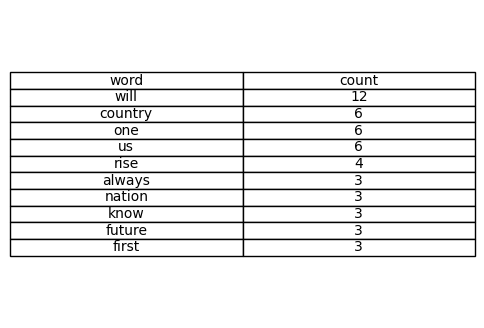

In [6]:
# export as csv
word_df.to_csv("word_counts.csv", index=False)
# create a table of the top 10 words and their counts and save as png table (but not csv)
top10 = word_df["word"].value_counts()[0:10]
top10_df = top10.reset_index()
top10_df.columns = ["word", "count"]
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis("off")
ax.table(cellText=top10_df.values, colLabels=top10_df.columns, cellLoc="center", loc="center")
plt.savefig("top10.png", bbox_inches="tight")
top10_df.to_csv("top10.csv", index=False)
plt.show()

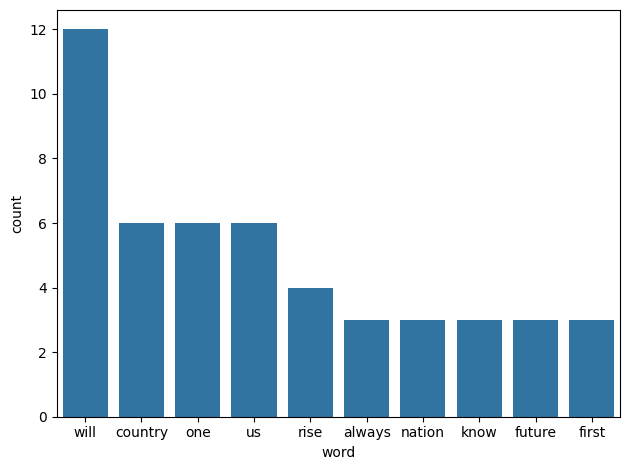

In [7]:
top10 = word_df["word"].value_counts().head(10)
sns.barplot(x=top10.index, y=top10)
plt.tight_layout()
plt.savefig("top10-sns.png")
plt.show()

## Word Clouds

Word clouds are a fun way to visualize the most common words in a dataset. The [WordCloud package](https://amueller.github.io/word_cloud/) provides a number of functions for making pretty images, with lots of customization.

Here's a basic word cloud. Note that the package requires a String as an input, not a DataFrame, so we first convert our cleaned and tokenized DataFrame back into a String.

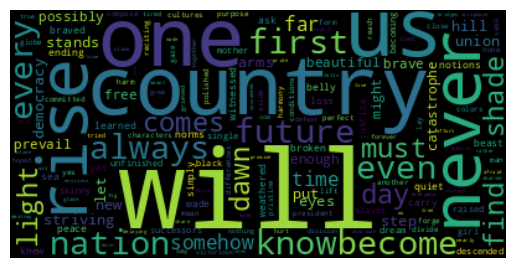

In [8]:
newtext = " ".join(word_df["word"])

# See the link above for options about shape, color, number of words, and so on.
cloud = WordCloud().generate(newtext)
plt.figure()
plt.imshow(cloud, interpolation="bilinear")
plt.axis("off")
plt.savefig("wordcloud.png")
plt.show()

### Intermezzo

Take some time to try one of the following challenges:
1. Insert a different poem or short story that you enjoy (you can just copy and paste it into the cell above), and look at its top words or make a word cloud. What can you learn from this?
2. Analyze the text of the novel *Black Amazon of Mars* by [Leigh Brackett](https://en.wikipedia.org/wiki/Leigh_Brackett), which I picked because I'm guessing you haven't read it. I grabbed this off of Project Gutenberg's website. You can load the text into a string (called `text`) using the following code:

In [9]:
import requests

text = requests.get("https://raw.githubusercontent.com/Greg-Hallenbeck/class-datasets/main/datasets/black%20amazon%20of%20mars.txt").text

# Relative Counts

In the first half, we considered a single text, and looked at the word counts. Here, we're going to compare the counts in two different documents (or two groups of documents), and look where words are more common. Some questions we may be interested in:

* If we compare the works of two authors (artists, poets, ...), how do their vocabularies differ?
* How do the words used in positive product reviews differ from negative product reviews?
* Are certain words more common in one music genre over another?
* *How are decriptions of Netflix movies and TV shows different? Are some words more common in one or the other?*

This last one is what we'll be investigating today. We'll do that by breaking the word counts into two groupings, then a bit of data manipulation and some data visualization.

### Frequencies vs. Counts

Today, we're interested in the frequency that a word shows up, rather than its raw counts. So, for example, I care whether a word shows up once every 100 words rather than it appearing in a document 5 times. Why? Because a longer document will naturally have more words in it, so to compare between documents we need to take that into account. So, instead of the raw counts, we'll calculate the *text frequency*:

$$TF = \text{text frequency} = \frac{\text{\# of times }word\text{ appears in a document}}{\text{total words in the document}}$$

Luckily, pandas does this for us when we add call `.count_values()` with the argument `normalize=True`. We then will calculate the relative frequency between two documents:

$$RF = \text{relative frequency} = \frac{TF \text{ document 1}}{TF \text{ document 2}}$$

### Log Ratio

Finally, we'll be taking a logarithm of these. Why? Because we want a $RF$ of $1/4$ to appear the same on a graph as a $RF$ of $4/1$: both represent a 4-to-1 ratio, it just depends on which document has more counts. Here is a visualization of several different ratios without transformation (left) and a log transformation (right):

<div style="text-align:center;"><img src="https://imgur.com/BxEAbMo.png"> <img src="https://imgur.com/59HkS1M.png"></div>

### Processing the Input

Let's load a dataset into a dataframe.

In [10]:
netflix = pd.read_csv("https://raw.githubusercontent.com/Greg-Hallenbeck/class-datasets/main/datasets/netflix.csv")
netflix.head(2)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,48,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,113,"['crime', 'drama']",['US'],NaN,tt0075314,8.3,795222.0,27.612,8.2


Instead of one string, this is a dataframe with many strings, which simplifies things significantly.

In [11]:
# Use nltk and pandas for tokenization, normalization, and unwanted token removal

def tokenize_description(desc):
    return nltk.word_tokenize(str(desc)) if pd.notnull(desc) else []
# Explode the dataframe so each word in 'description' becomes a row in a new 'word' column
df = netflix.copy()
df['word'] = df['description'].apply(tokenize_description)
df = df.explode('word').reset_index(drop=True)
# Normalize tokens and remove unwanted tokens (contractions + punctuation)
df['word'] = df['word'].str.replace("’", "'", regex=False).str.lower()
# count the rows in df
print(f"Number of rows in df: {len(df)}")
df

Number of rows in df: 255735


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,word
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,48,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN,this
1,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,48,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN,collection
2,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,48,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN,includes
3,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,48,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN,12
4,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,48,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN,world
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255730,ts271048,Mighty Little Bheem: Kite Festival,SHOW,"With winter behind them, Bheem and his townspe...",2021,NaN,0,"['family', 'comedy', 'animation']",[],1.0,tt13711094,8.8,16.0,0.979,10.0,the
255731,ts271048,Mighty Little Bheem: Kite Festival,SHOW,"With winter behind them, Bheem and his townspe...",2021,NaN,0,"['family', 'comedy', 'animation']",[],1.0,tt13711094,8.8,16.0,0.979,10.0,makar
255732,ts271048,Mighty Little Bheem: Kite Festival,SHOW,"With winter behind them, Bheem and his townspe...",2021,NaN,0,"['family', 'comedy', 'animation']",[],1.0,tt13711094,8.8,16.0,0.979,10.0,sankranti
255733,ts271048,Mighty Little Bheem: Kite Festival,SHOW,"With winter behind them, Bheem and his townspe...",2021,NaN,0,"['family', 'comedy', 'animation']",[],1.0,tt13711094,8.8,16.0,0.979,10.0,festival


For relative word counts, we'll just be looking at some binary category. Here, we'll use type, since it has two values: "SHOW" and "MOVIE", but we could also look at media released before and after 2000, or one with "TV-MA" and "R" ratings versus others. To simplify things, I'm going to throw out all columns except that category and the words.

In [12]:
import os
df["word"] = df["word"].str.replace("’", "'", regex=False).str.lower()
# Load unwanted tokens from external file
unwanted_path = os.path.join(os.path.dirname(os.getcwd()), 'week-06', 'unwanted_tokens.txt')
with open(unwanted_path, 'r', encoding='utf-8') as f:
    raw_lines = list(f)
    unwanted = set(line.strip() for line in raw_lines[1:] if line.strip())
df = df[~df["word"].isin(unwanted)]
print(f"Number of rows in df after cleaning: {len(df)}")
df = df[["type", "word"]]
df.head(100)

Number of rows in df after cleaning: 227134


,type,word
0,SHOW,this
1,SHOW,collection
2,SHOW,includes
3,SHOW,12
4,SHOW,world
...,...,...
109,MOVIE,battles
110,MOVIE,the
111,MOVIE,black
112,MOVIE,knight


### Word Counting
First, we remove stop words:

In [13]:
clean_words = df.loc[ ~df["word"].isin(STOPWORDS) ]

Then count them, just as we did before (after some grouping)

In [14]:
counts = clean_words.groupby("type")["word"].value_counts(normalize=True)


A quick inspection of the `counts` variable shows that there's some extremely rare text that we...probably don't want to keep. Let's remove anything with a very low frequency.

In [15]:
counts

type   word                  
MOVIE  life                      0.006926
       family                    0.004893
       love                      0.004824
       one                       0.004743
       young                     0.004410
                                   ...   
SHOW   ridiculous                0.000023
       girlfriend-turned-wife    0.000023
       bong                      0.000023
       webtoon                   0.000023
       sankranti                 0.000023
Name: proportion, Length: 30167, dtype: float64

In [16]:
# keep anything with a count > 0.0005
counts = counts[counts > 0.0005]

...and then convert it back to a dataframe.

In [17]:
counts.name = "text_freq"
counts = counts.reset_index()

In [18]:
counts.head()

,type,word,text_freq
0,MOVIE,life,0.006926
1,MOVIE,family,0.004893
2,MOVIE,love,0.004824
3,MOVIE,one,0.004743
4,MOVIE,young,0.004410


### Relative Frequency

This requires us to use `DataFrame.pivot()` which will let us directly compare the movie and TV show entries. Some [hopefully helpful documentation](https://pandas.pydata.org/docs/user_guide/reshaping.html) can be found here.

In [19]:
# pivot is from pandas
counts = counts.pivot(index='word', columns='type', values='text_freq')
counts = counts.reset_index()

In [20]:
# export as csv
counts.to_csv("netflix_word_counts.csv", index=False)

In [21]:
counts.head()

type,word,MOVIE,SHOW
0,across,0.000517,0.000563
1,adventure,0.000643,0.000743
2,adventures,NaN,0.001621
3,ago,NaN,0.000676
4,along,0.000666,0.000676


Then we fill in all the NAs with something below the minimum value for that type of media.

In [22]:
# Replace NaN values with half the minimum value in each column
# Notice that loc is used to avoid the SettingWithCopyWarning that can occur when trying to modify a DataFrame in place. This ensures that we are modifying the original DataFrame rather than a copy of it.
counts.loc[counts["MOVIE"].isna(), "MOVIE"] = counts["MOVIE"].min()/2
counts.loc[counts["SHOW"].isna(), "SHOW"]  = counts["SHOW"].min()/2

And calculate the movie/show word ratio, then a $\log(ratio)$

In [23]:
# column ratio should be the TF for MOVIE divided by TF for SHOW
# the division operation will make movies ratio > 1 and shows ratio < 1
counts["ratio"] = counts["MOVIE"]/counts["SHOW"]
counts["logratio"] = np.log10(counts["ratio"])

And finally, sort, so that we can see the words most strongly associated with movies and TV shows.

In [24]:
counts = counts.sort_values("logratio", ascending=True)

### Visualization

Now we've got a sorted DataFrame, which we can simply use to make a plot.

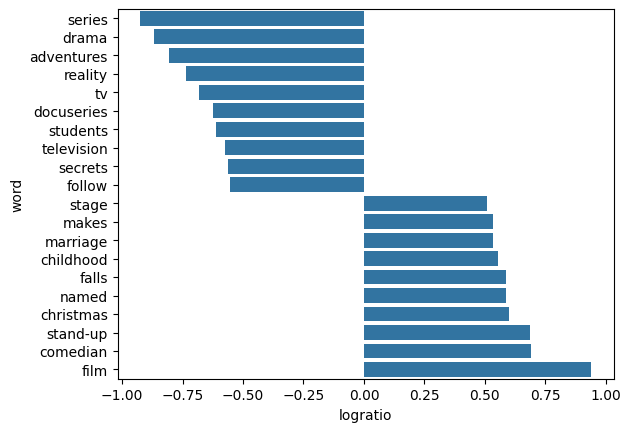

In [25]:
firstlast = pd.concat([  counts[0:10] , counts[-10:]  ])

# What kind of plot should I use?
sns.barplot(data=firstlast, x="logratio", y="word")
plt.show()

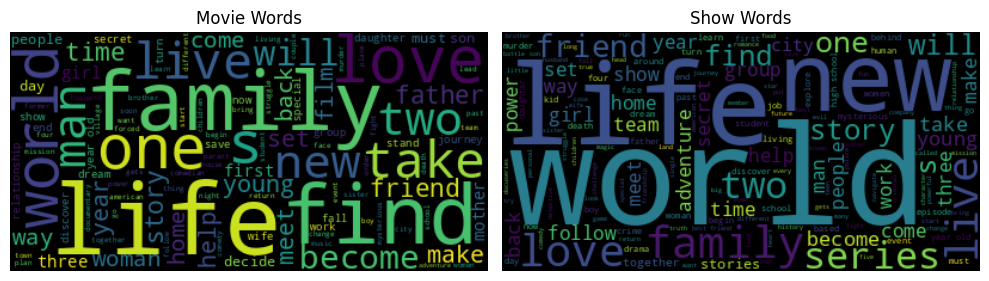

In [26]:
# add word clouds for each category, using the same method as before but with the subsetted dataframes
movie_words = " ".join(df[df["type"] == "MOVIE"]["word"])
show_words = " ".join(df[df["type"] == "SHOW"]["word"])
movie_cloud = WordCloud().generate(movie_words)
show_cloud = WordCloud().generate(show_words)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(movie_cloud, interpolation="bilinear")
plt.axis("off")
plt.title("Movie Words")
plt.subplot(1, 2, 2)
plt.imshow(show_cloud, interpolation="bilinear")
plt.axis("off")
plt.title("Show Words")
plt.tight_layout()
plt.savefig("netflix_wordclouds.png")
plt.show()


What words are most strongly associated with movie descriptions? With TV shows? Why?

- Left side (negative log ratio): Words more strongly associated with TV shows
- Right side (positive log ratio): Words more strongly associated with movies



### Challenges

Try one of the following challenges:

1. Split the netflix dataset by some other binary feature: rating (make sure to just have two possibilities!), produced before/after some year, or so on.
2. Compare the words used in spam vs real text messages. This is the [link to the dataset](https://github.com/Greg-Hallenbeck/class-datasets/blob/main/datasets/SMSSpamCollection.tsv).
3. Compare the words used in 1 star vs 5 star [reviews of hotels](https://raw.githubusercontent.com/Greg-Hallenbeck/class-datasets/main/datasets/tripadvisor_hotel_reviews.csv).